# Task 1: Version Control and AI-assisted Coding
## Version Control Notes:
Although this is a assignment worked on by an individual with tasks in sequence, a proper git workflow will be followed as follows, where each other numbered task will be assigned to their individual branch and worked on and committed until completion before being merged back into main as if it was an implmentation of an independent 'feature'.

## AI-Assisted Coding Notes:
Regarding the mandatory A.I. tool useage, to assist in readability, relevant prompts and generated code will be documented within this jupyter notebook file as individual cells with modifications and analysis following. In addition, as specified in the assignment description, these prompts will be also be documented in a separate text file for posterity. 

## Task 2: Image Deblurring
The first task of the assignment is to explore various image deblurring methods and compare their various features and limitations. As the assignment description has named some specific classical examples, such as Wiener and Richardson-Lucy we will begin replicating these techniques into code.

To meet the Assignment's specification of integrating AI assisted coding, we will ask Google Gemini to provide a simple example with the following prompt: 


**Prompt to Google Gemini:** "Example of implementing Weiner deblurring technique in Python"

The following Code example was then generated and ran:

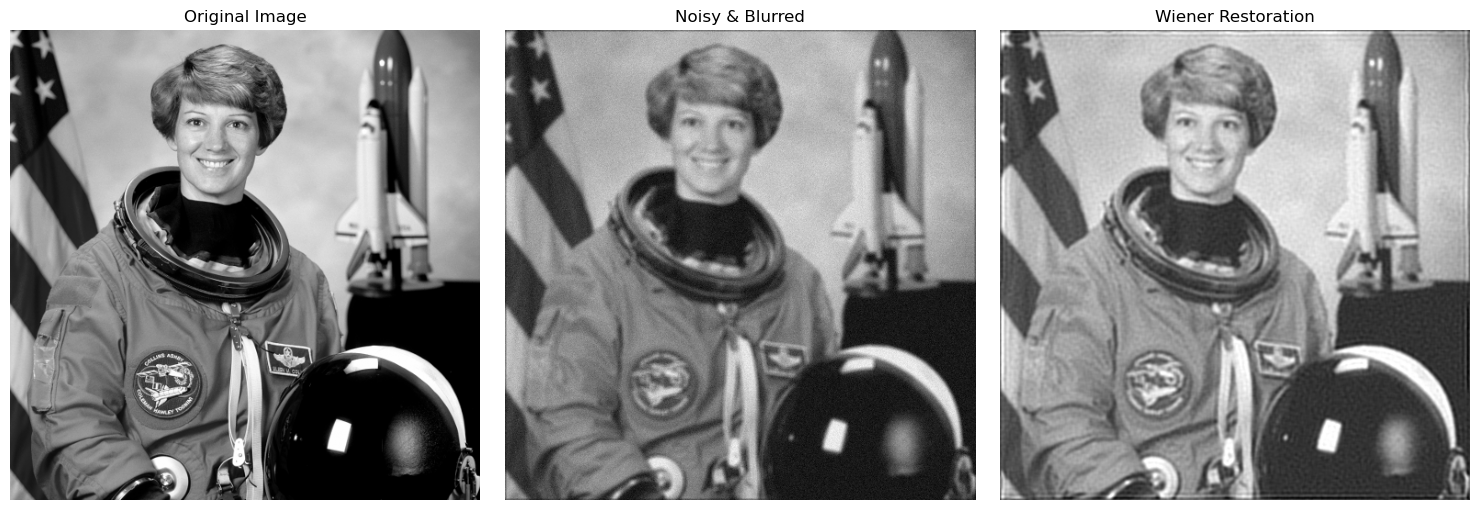

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, data, restoration
from scipy.signal import convolve2d
from PIL import Image

# 1. Load a sample image and convert to grayscale
astro = color.rgb2gray(data.astronaut())
plt.imsave('og_astronaut.jpg', astro, cmap='gray')

# 2. Create a PSF (Point Spread Function) - in this case, a Gaussian blur
psf = np.ones((5, 5)) / 25

# 3. Simulate blur and add Gaussian noise
blurred_astro = convolve2d(astro, psf, 'same')
# Add a bit of random noise
noisy_blurred = blurred_astro + 0.1 * blurred_astro.std() * np.random.standard_normal(blurred_astro.shape)

plt.imsave('blurred_astronaut.jpg', noisy_blurred, cmap='gray')

# 4. Apply Wiener Filter
# The 'balance' parameter is the ratio of noise power to signal power.
# A smaller balance (e.g., 0.01) assumes less noise.
deconvolved_astro = restoration.wiener(noisy_blurred, psf, balance=0.05)
plt.imsave('wiener_astronaut.jpg', deconvolved_astro, cmap='gray')

# 5. Visualization
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

ax[0].imshow(astro, cmap='gray')
ax[0].set_title('Original Image')

ax[1].imshow(noisy_blurred, cmap='gray')
ax[1].set_title('Noisy & Blurred')

ax[2].imshow(deconvolved_astro, cmap='gray')
ax[2].set_title('Wiener Restoration')

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

Further reading, from both the Gemini output as well as additional sources such as: https://www.owlnet.rice.edu/~elec539/Projects99/BACH/proj2/blind/bd.html provides context on classical deblur filtering techniques. In summary, these classical techniques in general operate on presumptions in modelling the degradation of an image's quality as that of a 'blurring function' as well as presumptions of 'spectral density' and 'spectral noise', which can often be estimated by comparative examples. Through these presumptions image quality is 'restored' through applying inverse filtering and noise smoothing functions which the Wiener Filter specifically tries to optimise weightings between based on a Mean Square Error (MSE) calculation (lifted from Wikipedia https://en.wikipedia.org/wiki/Wiener_deconvolution): 

\begin{aligned}G(f)&={\frac {1}{H(f)}}\left[{\frac {1}{1+1/(|H(f)|^{2}\mathrm {SNR} (f))}}\right]\end{aligned}

Classical deblurring techniques however are limited in performance from these presumptions and are referred to as 'non-blind deconvolution' while in practice there are often significant discrepancies with these simplistic model's assumptions. For example: the estimation blur might not be sufficiently estimatable, high frequency noise will be amplified just as if it was a sharp detail, a presumption that the blur applied across an image is consistent is often not correct (i.e. moving objects have more 'blur' to them than static ones in the same shot), boundary effects and information loss in real images are not able to be considered leading to compromises in the restored image. 




Although an extreme case. These limitations can be showcased by applying the same technique to a sparse image containing an object in motion, a clock, which produces a result that fails completely as demonstrated below:


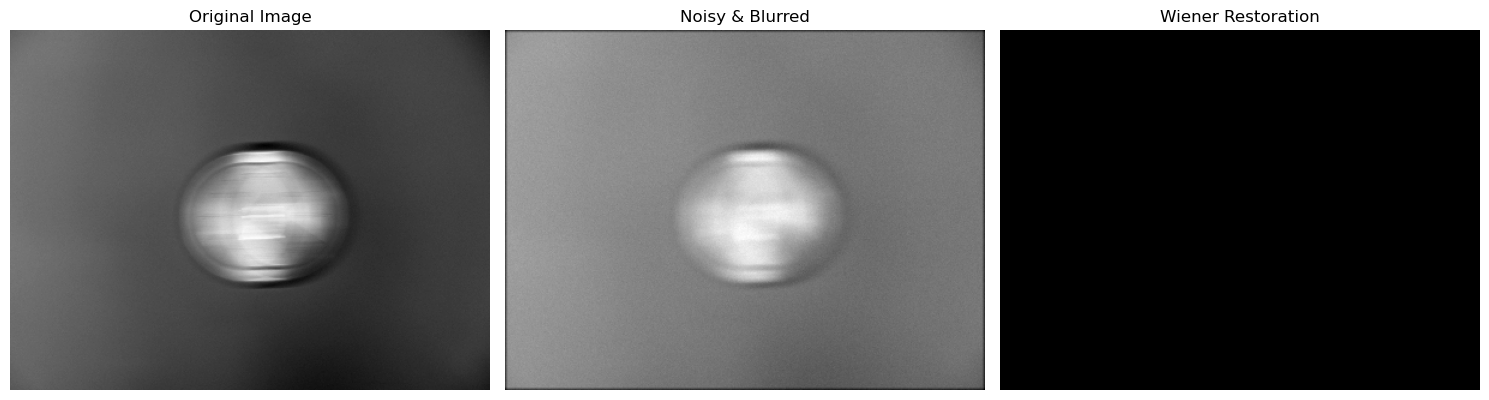

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, data, restoration
from scipy.signal import convolve2d

# 1. Load a sample image and convert to grayscale
clock = data.clock()
plt.imsave('og_clock.jpg', clock, cmap='gray')

# 2. Create a PSF (Point Spread Function) - in this case, a Gaussian blur
psf = np.ones((5, 5)) / 25

# 3. Simulate blur and add Gaussian noise
blurred_clock = convolve2d(clock, psf, 'same')
# Add a bit of random noise
noisy_blurred = blurred_clock + 0.1 * blurred_clock.std() * np.random.standard_normal(blurred_clock.shape)
plt.imsave('blurred_clock.jpg', noisy_blurred, cmap='gray')

# 4. Apply Wiener Filter
# The 'balance' parameter is the ratio of noise power to signal power.
# A smaller balance (e.g., 0.01) assumes less noise.
deconvolved_clock = restoration.wiener(noisy_blurred, psf, balance=0.05)
plt.imsave('wiener_clock.jpg', deconvolved_clock, cmap='gray')

# 5. Visualization
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

ax[0].imshow(clock, cmap='gray')
ax[0].set_title('Original Image')

ax[1].imshow(noisy_blurred, cmap='gray')
ax[1].set_title('Noisy & Blurred')

ax[2].imshow(deconvolved_clock, cmap='gray')
ax[2].set_title('Wiener Restoration')

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

These techniques are therefore referred to as classical as they have been conventionally deprecated in favour of more modern approaches such as Deep Learning modelling which can produce much higher parametised modeling, mitigating a lot of the presumptions from classical techniques. As such it is expected a sufficiently trained Deep Learning model will generally eclipse the performance of classical techniques, at the cost of substantive computational cost in training and processing. Biases towards conforming to training set data is however an additional risk for consideration when using Deep Learning models over that of more inherently generalised and interpretable classical techniques.  

There are ethical risks to consider when applying machine learning techniques to perform such a task however, especially in conjunction with the prevalence of prominence of generative A.I. Deblurring is not a technique that 'should' be able to recover absent data. Or otherwise hallucinate details that are simply absent. An example of deep learning techniques stepping out of bounds from statistical inference to generative fabrication is given in the following article: 
https://www.eco-business.com/news/ai-edited-wildlife-photo-in-japan-reignites-debate-over-technologys-expanding-role-in-conservation/ where the image below was produced from supposedly 'deblurring' using generative A.I.

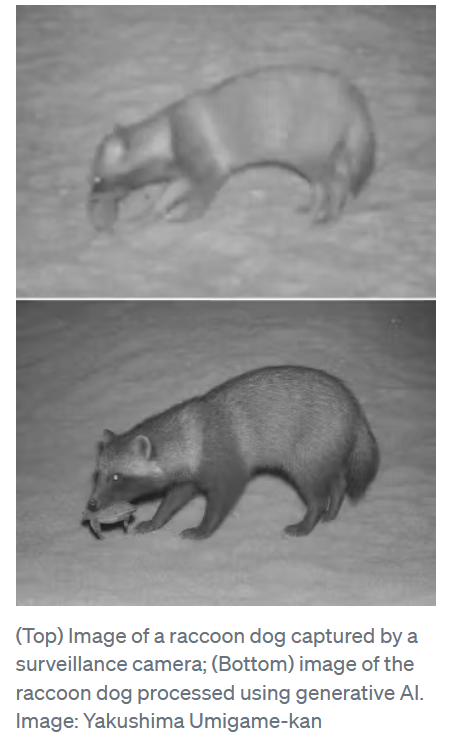

Although a seemingly benign example, this produced image is a complete fabrication inadmissable as truth (note the change in pose and focus of the held object). Conflation of various machine learning applications has resulted in an image generated through A.I. attempted to be passed off as a real image that has been enhanced. 

Additionally deep learning techniques also presume that the images it will be applied on are comparable to the images it is trained on, creating a bias when restoring image quality. Another more famous and extreme tangential example of this bias can be demonstrated by machine learning being used to enhance image quality of a low resolution picture as follows:  

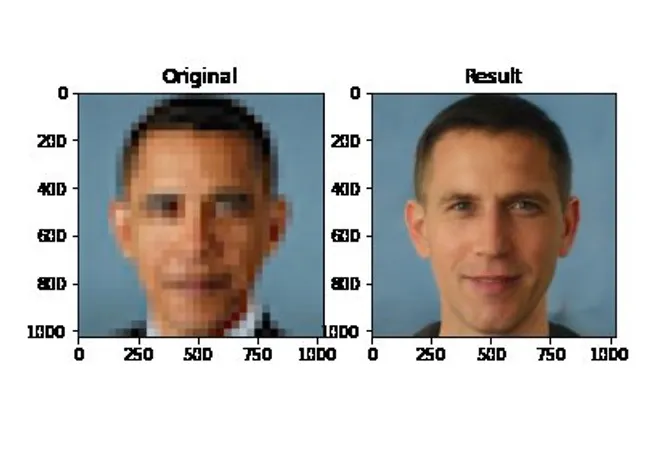

Nevertheless when applied correctly Deep Learning and other Machine Learning techniques can be a powerful tool for producing statistical inference that is otherwise unfeasible through any classical techniques. However all of these necessitates a dataset in which to be trained upon. Rather than using a pretrained model, for learning purposes we will train our own much more primitive model.

For this basic example we have prepared a simple dataset for training being the first 100 images of the coco2017 validation dataset with blur added taken from here: https://www.kaggle.com/datasets/iamravigarg/cocoblur along with the original version of these images taken from here:  https://www.kaggle.com/datasets/iamravigarg/cocoblur. These datasets can be observed in the 'samples-blurred' and 'samples-og' directories respectively.



Using Google Gemini to "Provide a code example to train a deep learning model to deblur a dataset containing 100 original and blurred images using PyTorch" and additional prompting and debugging we are able to generate the following code example:  

In [38]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import os
from PIL import Image

class DeblurDataset(Dataset):
    def __init__(self, blur_dir, sharp_dir, patch_size=256):
        self.blur_imgs = sorted([f for f in os.listdir(blur_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
        self.sharp_imgs = sorted([f for f in os.listdir(sharp_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
        self.blur_dir = blur_dir
        self.sharp_dir = sharp_dir
        self.patch_size = patch_size
        self.transform = transforms.ToTensor()

    def __getitem__(self, idx):
        blur = Image.open(os.path.join(self.blur_dir, self.blur_imgs[idx])).convert("RGB")
        sharp = Image.open(os.path.join(self.sharp_dir, self.sharp_imgs[idx])).convert("RGB")

        # --- SAFETY FIX: Resize if image is smaller than patch_size ---
        w, h = blur.size
        if h < self.patch_size or w < self.patch_size:
            new_h = max(h, self.patch_size)
            new_w = max(w, self.patch_size)
            blur = F.resize(blur, (new_h, new_w))
            sharp = F.resize(sharp, (new_h, new_w))

        # Now RandomCrop will always work
        i, j, h, w = transforms.RandomCrop.get_params(blur, output_size=(self.patch_size, self.patch_size))
        blur = F.crop(blur, i, j, h, w)
        sharp = F.crop(sharp, i, j, h, w)

        return self.transform(blur), self.transform(sharp)
    
    def __len__(self):
        # This tells the DataLoader how many images you have (100 in your case)
        return len(self.blur_imgs)

In [39]:
class SimpleDeblurUNet(nn.Module):
    def __init__(self):
        super(SimpleDeblurUNet, self).__init__()
        # Encoder (Downsampling)
        self.enc1 = self.conv_block(3, 64)
        self.enc2 = self.conv_block(64, 128)
        self.pool = nn.MaxPool2d(2)
        
        # Decoder (Upsampling)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(128, 64) # 128 because of skip connection
        self.final = nn.Conv2d(64, 3, kernel_size=1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        s1 = self.enc1(x)
        p1 = self.pool(s1)
        s2 = self.enc2(p1)
        
        u1 = self.up1(s2)
        # Skip connection: attach s1 (the initial details) to the upsampled output
        c1 = torch.cat([u1, s1], dim=1)
        d1 = self.dec1(c1)
        return self.final(d1)

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F
from tqdm import tqdm # For a nice progress bar

# 1. Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Initialize Model, Loss, and Optimizer
model = SimpleDeblurUNet().to(device)
criterion = nn.L1Loss() 
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Define your paths (Change these to your actual folder locations)
BLUR_PATH = "./samples-blurred"
SHARP_PATH = "./samples-og"

# Create the dataset instance
train_ds = DeblurDataset(blur_dir=BLUR_PATH, sharp_dir=SHARP_PATH, patch_size=256)

# Now the DataLoader will work
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

# 3. Create DataLoaders
# Assuming 'train_ds' is the DeblurDataset instance from the previous step
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

# 4. Training Loop
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for blur_img, sharp_img in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        blur_img = blur_img.to(device)
        sharp_img = sharp_img.to(device)
        
        # Forward pass
        outputs = model(blur_img)
        loss = criterion(outputs, sharp_img)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

    # Optional: Save checkpoint every 20 epochs
    if (epoch + 1) % 20 == 0:
        torch.save(model.state_dict(), f'deblur_model_epoch_{epoch+1}.pth')

Epoch 1: 100%|█████████████████████████████████████████████████████████████████████████| 13/13 [00:04<00:00,  2.72it/s]


Epoch [1/100], Loss: 0.3440


Epoch 2: 100%|█████████████████████████████████████████████████████████████████████████| 13/13 [00:02<00:00,  4.97it/s]


Epoch [2/100], Loss: 0.2482


Epoch 3: 100%|█████████████████████████████████████████████████████████████████████████| 13/13 [00:02<00:00,  5.03it/s]


...

Epoch [98/100], Loss: 0.0482


Epoch 99: 100%|████████████████████████████████████████████████████████████████████████| 13/13 [00:02<00:00,  4.81it/s]


Epoch [99/100], Loss: 0.0503


Epoch 100: 100%|███████████████████████████████████████████████████████████████████████| 13/13 [00:02<00:00,  4.75it/s]

Epoch [100/100], Loss: 0.0502


Now that we have trained a simple Convolutional Neural Network Deep Learning deblurring model we can do a single image inference test as a sanity check for peformance. Applying this model on that blurred Astronaut from earlier we are able to cursory compare this model's performance with that of the classical Wiener filter as follows:

In [82]:
import torch
import torchvision.transforms.functional as F
from PIL import Image
from skimage import color, data, restoration
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def deblur_image(model_path, image_path, save_path):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. Load the trained model
    model = SimpleDeblurUNet().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval() # Set to evaluation mode
    
    # 2. Load and Pre-process image
    img = Image.open(image_path).convert("RGB")
    
    # Ensure dimensions are multiples of 16 (required for U-Net)
    w, h = img.size
    new_w = (w // 16) * 16
    new_h = (h // 16) * 16
    img = img.resize((new_w, new_h), Image.LANCZOS)
    
    input_tensor = F.to_tensor(img).unsqueeze(0).to(device) # Add batch dimension
    
    # 3. Perform Inference
    with torch.no_grad():
        output = model(input_tensor) # This is a Tensor
    
    # 4. Save Result (The Corrected Part)
    # Remove batch dim, move to CPU, and ensure pixels are in [0, 1] range
    output_tensor = output.squeeze(0).cpu().clamp(0, 1)
    
    # Use to_pil_image (NOT to_tensor)
    output_pil = F.to_pil_image(output_tensor)
    output_pil.save(save_path)


Text(0.5, 1.0, 'Wiener Deblurring')

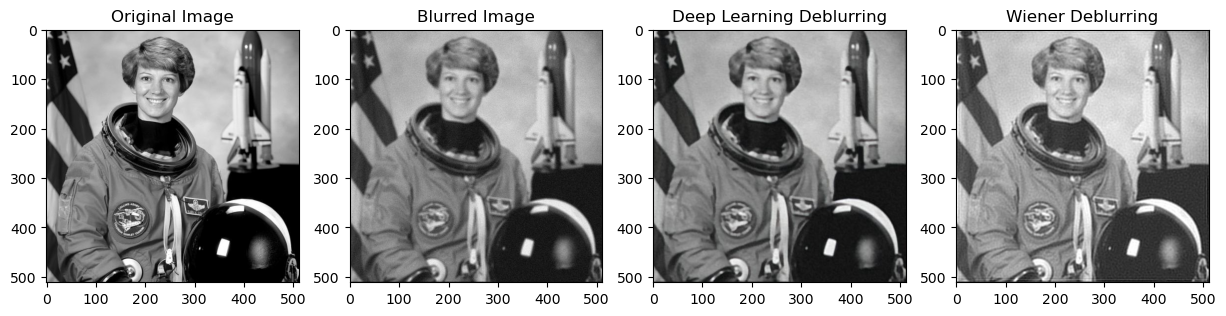

In [83]:
# Run it
deblur_image("deblur_model_epoch_100.pth", "blurred_astronaut.jpg", "cnn_astronaut.jpg")

image0 = plt.imread("og_astronaut.jpg")
image1 = plt.imread("blurred_astronaut.jpg")
image2 = plt.imread("cnn_astronaut.jpg")
image3 = plt.imread("wiener_astronaut.jpg")

# 5. Visualization
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(15, 5))
ax[0].imshow(image0, cmap='gray')
ax[0].set_title('Original Image')

ax[1].imshow(image1, cmap='gray')
ax[1].set_title('Blurred Image')

ax[2].imshow(image2, cmap='gray')
ax[2].set_title('Deep Learning Deblurring')

ax[3].imshow(image3, cmap='gray')
ax[3].set_title('Wiener Deblurring')

Although not an objective performance evaluation from a single arbitrary example, the result from CNN seems favourable compared to classical techniques given how rudimentary our model and training sets are. Following this example with the sparse clock in motion image:

Text(0.5, 1.0, 'Wiener Deblurring')

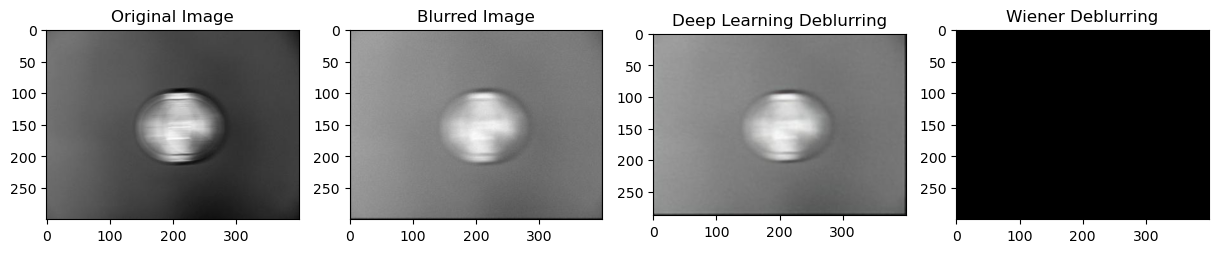

In [84]:
# Run it
deblur_image("deblur_model_epoch_100.pth", "blurred_clock.jpg", "cnn_clock.jpg")

image0 = plt.imread("og_clock.jpg")
image1 = plt.imread("blurred_clock.jpg")
image2 = plt.imread("cnn_clock.jpg")
image3 = plt.imread("wiener_clock.jpg")

# 5. Visualization
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(15, 5))
ax[0].imshow(image0, cmap='gray')
ax[0].set_title('Original Image')

ax[1].imshow(image1, cmap='gray')
ax[1].set_title('Blurred Image')

ax[2].imshow(image2, cmap='gray')
ax[2].set_title('Deep Learning Deblurring')

ax[3].imshow(image3, cmap='gray')
ax[3].set_title('Wiener Deblurring')

Although its hard to assess much improvement given how poor the original image is, it can be seen that CNN doesn't completely fail this example like Wiener filtering does.

We will proceed to more formal analysis of these two examples evaluating the Peak Signal to Noise Ratio (PSNR) and Structural Similarity Index (SSIM). Although we can compare a number of different Deep Learning models we will simply perform the analysis upon the CNN developed above along with the Wiener filter and note that pretrained models exist such as NAFNet MPRNet and HINet that have various tradeoffs in general performance, computation costs and specialisations on specific datasets (i.e. GoPro data).  

In [89]:
import cv2
from skimage import metrics

def compare_images(sharp_path, deblurred_path):
    # 1. Load the images
    # OpenCV loads images in BGR format by default
    img_sharp = cv2.imread(sharp_path)
    img_deblurred = cv2.imread(deblurred_path)

    if img_sharp is None or img_deblurred is None:
        print("Error: Could not load one of the images. Check the file paths.")
        return

    # 2. Pre-processing: Ensure images are the same size
    # Metrics require identical dimensions
    if img_sharp.shape != img_deblurred.shape:
        print(f"Resizing deblurred image from {img_deblurred.shape[:2]} to {img_sharp.shape[:2]}")
        img_deblurred = cv2.resize(img_deblurred, (img_sharp.shape[1], img_sharp.shape[0]))

    # 3. Calculate PSNR
    # Higher is better. Typically >30dB is considered good quality.
    psnr_value = metrics.peak_signal_noise_ratio(img_sharp, img_deblurred)

    # 4. Calculate SSIM
    # Value ranges from -1 to 1. 1 means identical.
    # We specify channel_axis=-1 for color (RGB/BGR) images.
    ssim_value = metrics.structural_similarity(img_sharp, img_deblurred, channel_axis=-1)

    print(f"--- Comparison Results ---")
    print(f"PSNR: {psnr_value:.2f} dB")
    print(f"SSIM: {ssim_value:.4f}")

# Usage
print("Astronaut Deblurring Comparison, CNN Deblurring:")
compare_images('og_astronaut.jpg', 'cnn_astronaut.jpg')

print("Astronaut Image Comparison, Wiener Filter:")
compare_images('og_astronaut.jpg', 'wiener_astronaut.jpg')

print("Clock Image Comparison, CNN Deblurring:")
compare_images('og_clock.jpg', 'cnn_clock.jpg')

print("Clock Image Comparison, Wiener Filter:")
compare_images('og_clock.jpg', 'wiener_clock.jpg')

Astronaut Deblurring Comparison, CNN Deblurring:
--- Comparison Results ---
PSNR: 23.16 dB
SSIM: 0.7062
Astronaut Image Comparison, Wiener Filter:
--- Comparison Results ---
PSNR: 17.55 dB
SSIM: 0.6475
Clock Image Comparison, CNN Deblurring:
Resizing deblurred image from (288, 400) to (300, 400)
--- Comparison Results ---
PSNR: 13.97 dB
SSIM: 0.8056
Clock Image Comparison, Wiener Filter:
--- Comparison Results ---
PSNR: 9.15 dB
SSIM: 0.0015


From these results we can more objectively infer the performance of these filtering techniques. The first value PSNR measures the ratio between the maximum 'power' of valid signal data with that of noise. 

The second value SSIM measures 'perceptual similarity based on Luminance, Constrast and Structure between the images. This metric is meant to more closely align with how 'humans' would consider similarity between images because it puts greater weight on retaining edge and texture. The higher value the better with a maximum value of 1.0 denoting identical structure.

We can see that these values that the simple CNN filter outperforms the Wiener filter on these two examples. Interesting to note is that PSNR still has a relatively high value for the 'blank' image produced by Wiener filtering the clock image while the SSIM value plummets, this showcases the distinction above between what these two values are evaluating. 

Although further evaluations could be performed on a larger suite of images it is believed that these examples are sufficient to show an understanding of the discrepancy between classical and deep learning deblurring techniques, their tradeoffs amd showing examples of performing quantitive evaluation in performance and edge case examples showcasing limitations with both methods.  

## Task 3: Object Detection and Analysis



## Task 4: Training Data Preparation and Training for Blurry Object Detection

## Task 5: Performance Comparison and Critical Analysis

In [ ]:
from ultralytics import YOLO
import cv2

# 1. Load the model
# 'yolo11n.pt' is the 'nano' version - fast and lightweight. 
# It will auto-download on the first run.
model = YOLO('yolo11n.pt') 

# 2. Run inference on an image
# You can pass a URL, a local path, or a numpy array
results = model('https://ultralytics.com/images/bus.jpg')

# 3. Process the results
for result in results:
    # Display the image with bounding boxes using the built-in visualizer
    annotated_frame = result.plot()
    
    # Show the result in a window
    cv2.imshow("YOLO Object Detection", annotated_frame)
    
    # Wait for a key press and close the window
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # Optional: Save the result to a file
    # result.save(filename='detected_objects.jpg')


image 1/1 D:\2026 Uni\CompVision\Ass1Git\CompVision-Ass1\code\bus.jpg: 640x480 4 persons, 1 bus, 33.2ms
Speed: 4.9ms preprocess, 33.2ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 480)


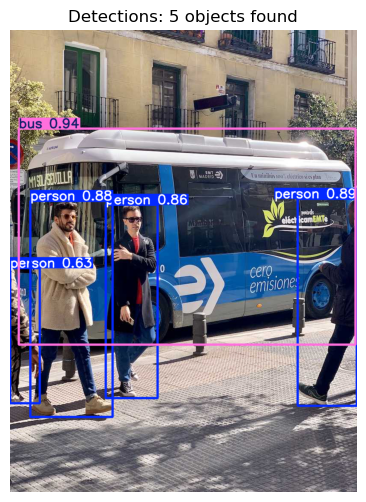

In [7]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

def run_yolo_detection(image_path):
    # 1. Load a pre-trained YOLO model (n = nano, fast and lightweight)
    model = YOLO('yolo11n.pt') 

    # 2. Run inference on the image
    # We set stream=False to get a list of Results objects
    results = model(image_path)

    # 3. Process the results
    for result in results:
        # Get the original image in BGR (OpenCV format)
        # result.plot() returns a numpy array with boxes drawn
        annotated_img = result.plot()

        # 4. Convert BGR to RGB for Matplotlib
        img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

        # 5. Plotting with Matplotlib
        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.title(f"Detections: {len(result.boxes)} objects found")
        plt.axis('off')  # Hide X and Y axes
        plt.show()

# Run the function
run_yolo_detection('bus.jpg')